In [1]:
!nvidia-smi

Mon Aug 17 16:11:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# ImageNet-1k Inference Noise Sweep

This notebook evaluates the network-level effect of the photonic multiplier error models on
the full 50,000-image ImageNet-1k validation set.

The sweep uses pretrained AlexNet, ResNet18 and VGG19 models, five photonic noise levels and
three independent network-noise draws per point. Four numerical behaviours are evaluated:
the uncorrected 4-bit baseline, non-uniform slicing, parallel MSB-corner correction and
low-bit decomposed correction. These represent the four distinct numerical behaviours of
the six component-level implementations, since the direct 4-bit corner LUT and parallel
corner correction are equivalent under the ideal-table model, as are the two low-bit
implementations.

Completed evaluations are checkpointed after every run so that long ImageNet sweeps can be
resumed without repeating finished model, scheme, noise and seed combinations.


## 1. Configuration

The default configuration evaluates AlexNet, ResNet18 and VGG19 on all 50,000 ImageNet-1k
validation images.

ImageNet-1k is gated on Hugging Face. Before the first Colab run, accept access to
`ILSVRC/imagenet-1k` and add a read token to Colab Secrets as `HF_TOKEN`. If the secret is
not available, the dataset-preparation cell prompts for a token securely.

The validation set is streamed once and materialised as a normal `ImageFolder`. Local Colab
storage is used when enough space is available, otherwise the notebook falls back to Google
Drive. Later runs reuse the prepared directory.


In [2]:
# ============================================================
#                     CONFIGURATION
# ============================================================

USE_GOOGLE_DRIVE = True
DRIVE_RESULTS_ROOT = "/content/drive/MyDrive/Thesis/bitlume_results"

# Hugging Face ImageNet-1k source. Only the validation split is used.
HF_IMAGENET_REPO = "ILSVRC/imagenet-1k"

# Temporary tiny cache for streaming metadata only.
HF_CACHE_DIR = "/content/hf_imagenet_stream_cache"

# Prepared ImageFolder targets. The notebook chooses one automatically.
LOCAL_IMAGEFOLDER_ROOT = "/content/imagenet_val_imagefolder"
DRIVE_IMAGEFOLDER_ROOT = "/content/drive/MyDrive/datasets/imagenet_val_imagefolder"

# Full inference set used for the thesis results.
MODEL_SET = "full"        # "fast" = AlexNet + ResNet18 | "full" = + VGG19

DATASET = "imagenet"
N_IMAGES = None           # None = all 50,000 ImageNet validation images
BATCH_SIZE = 128

SIGMA_SWEEP = [2.7588, 11.0, 22.0, 44.0, 88.0]

N_SEEDS = 3
PRECISIONS = ["FP16"]
SCHEMES = ["base", "nonuni", "parallel", "lowbit"]

N_CHARACTERISE = 40000
SEED = 42
NUM_WORKERS = 4

# Space planning.
MIN_FREE_GB_LOCAL = 10.0     # local /content threshold to build the 50k-val ImageFolder safely

MODELS = ["alexnet", "resnet18"] if MODEL_SET == "fast" else ["alexnet", "resnet18", "vgg19"]
# Legacy tag retained so the notebook can find the checkpoint produced by the original run.
RUN_TAG = f"imagenet_{'full50k' if N_IMAGES is None else str(N_IMAGES)}_{MODEL_SET}_fully_fixed"

# Historical resume helper. The original execution completed AlexNet and ResNet18,
# was stopped, and was later restarted to finish VGG19 from the saved checkpoint.
# Leave False for a fresh full run. Set True only to reproduce that resume path.
RESUME_VGG19_ONLY = False

print("Configuration")
print(f"  Models     : {MODELS}")
print(f"  Dataset    : {HF_IMAGENET_REPO} / validation")
print(f"  Images/run : {'all 50,000' if N_IMAGES is None else f'{N_IMAGES:,}'}")
print(f"  Sigmas     : {SIGMA_SWEEP}")
print(f"  Schemes    : {SCHEMES}")
print(f"  Seeds      : {N_SEEDS}")
print(f"  Precisions : {PRECISIONS}")

_n_eval = len(MODELS) * len(SIGMA_SWEEP) * len(SCHEMES) * len(PRECISIONS) * N_SEEDS
print(f"\n  Noisy evaluations : {_n_eval}  (+ {len(MODELS)} clean references)")

_image_scale = 5.0 if N_IMAGES is None else N_IMAGES / 10000.0
_sec_10k = {"alexnet": 37, "resnet18": 36, "vgg19": 86}
_tot = sum(_sec_10k[m] * _image_scale for m in MODELS) * \
       len(SIGMA_SWEEP) * len(SCHEMES) * len(PRECISIONS) * N_SEEDS
_tot += sum(_sec_10k[m] * _image_scale for m in MODELS)
print(f"  Rough L4 estimate : {_tot/3600:.2f} hours")
print("  Results are saved to Drive after every evaluation, so a Colab reset is resumable.")


Configuration
  Models     : ['alexnet', 'resnet18', 'vgg19']
  Dataset    : ILSVRC/imagenet-1k / validation
  Images/run : all 50,000
  Sigmas     : [2.7588, 11.0, 22.0, 44.0, 88.0]
  Schemes    : ['base', 'nonuni', 'parallel', 'lowbit']
  Seeds      : 3
  Precisions : ['FP16']

  Noisy evaluations : 180  (+ 3 clean references)
  Rough L4 estimate : 13.47 hours
  Results are saved to Drive after every evaluation, so a Colab reset is resumable.


In [3]:
import os, math, time, json, shutil, sys, subprocess, getpass
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

RESULT_ROOT = DRIVE_RESULTS_ROOT if (IN_COLAB and USE_GOOGLE_DRIVE) else "/content/bitlume_results"
os.makedirs(RESULT_ROOT, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)

print(f"PyTorch      : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"Device       : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU detected. In Colab use Runtime > Change runtime type > GPU.")


Mounted at /content/drive
PyTorch      : 2.11.0+cu128
torchvision  : 0.26.0+cu128
Device       : cuda
GPU          : NVIDIA L4


In [4]:
# Optional checkpoint inspection.
#
# This diagnostic was added during the original experiment after execution was stopped
# before VGG19 had finished. It was used to confirm which evaluations had already been
# checkpointed before restarting the notebook. It is safe to leave in the notebook because
# it does not change the evaluation state.

RESULT_PATH = os.path.join(
    DRIVE_RESULTS_ROOT if (IN_COLAB and USE_GOOGLE_DRIVE) else "/content/bitlume_results",
    f"sweep_results_{RUN_TAG}.json",
)

print("Checkpoint exists:", os.path.exists(RESULT_PATH))

if os.path.exists(RESULT_PATH):
    with open(RESULT_PATH, "r") as f:
        checkpoint = json.load(f)

    vgg = {k: v for k, v in checkpoint.items() if k.startswith("vgg19|")}

    print("TOTAL SAVED:", len(checkpoint))
    print("VGG19 SAVED:", len(vgg))
    print("VGG19 NOISY:", sum("|clean|" not in k for k in vgg))

    if vgg:
        print("\nLast VGG19 entries:")
        for k, v in list(vgg.items())[-10:]:
            print(k, "=", v)
else:
    print("No checkpoint yet. A fresh run will create one after the first evaluation.")


Checkpoint exists: True
TOTAL SAVED: 166
VGG19 SAVED: 44
VGG19 NOISY: 43

Last VGG entries:
vgg19|lowbit|FP16|22.0|0 = 70.422
vgg19|lowbit|FP16|22.0|1 = 70.424
vgg19|lowbit|FP16|22.0|2 = 70.26
vgg19|base|FP16|44.0|0 = 66.164
vgg19|base|FP16|44.0|1 = 66.12
vgg19|base|FP16|44.0|2 = 66.058
vgg19|nonuni|FP16|44.0|0 = 71.166
vgg19|nonuni|FP16|44.0|1 = 71.262
vgg19|nonuni|FP16|44.0|2 = 71.114
vgg19|parallel|FP16|44.0|0 = 72.082


## 2. Stage A: Characterise the Multiplier

Stage A runs the exact component-level multiplication model on 40,000 normalised mantissa
pairs for each scheme and noise level. The resulting relative-error mean and standard
deviation are passed to the network-level model in Stage B.

Operands are sampled from the normalised mantissa range `[2^(p-1), 2^p)` so that the leading
bit is set. This avoids mixing the network characterisation with the small-operand behaviour
of the canonical component experiment.

Runtime 2-bit by 2-bit correction terms are exact lookup-table values and do not receive the
extrapolated 2-bit noise model. Mixed 2-bit by 4-bit terms in the non-uniform scheme use the
4-bit error model. The extrapolated 2-bit parameters are retained only as part of the
component-model parameter set.


In [5]:
# LightMat-HP error parameters by operand bit width. The d=2 row is EXTRAPOLATED.
ERROR_PARAMS = {2: (0.0219, 0.1693), 3: (0.2144, 0.7048), 4: (0.2041, 2.7588)}
SIGMA_RATIO = {d: ERROR_PARAMS[d][1] / ERROR_PARAMS[4][1] for d in ERROR_PARAMS}
MU_RATIO    = {d: ERROR_PARAMS[d][0] / ERROR_PARAMS[4][0] for d in ERROR_PARAMS}

def mu_for(sigma):
    """Systematic bias scales with sigma, anchored on LightMat's 4-bit pair."""
    return 0.2041 * (sigma / 2.7588)

MANTISSA_BITS = {"FP16": 12, "FP32": 24}

# The 16-entry 2-bit product table, shared by schemes 2, 3 and 4
LUT_2BIT = np.array([[x * y for y in range(4)] for x in range(4)], dtype=np.int64)

def residue_decomposed(a_nib, b_nib):
    """(a*b) mod 16 from three reads of the 16-entry 2-bit table.
    a*b = 16(a_hi b_hi) + 4(a_hi b_lo + a_lo b_hi) + a_lo b_lo, and the first term
    vanishes mod 16, so the a_hi*b_hi product is never needed."""
    ah, al = a_nib >> 2, a_nib & 3
    bh, bl = b_nib >> 2, b_nib & 3
    return (4 * (LUT_2BIT[ah, bl] + LUT_2BIT[al, bh]) + LUT_2BIT[al, bl]) % 16

assert all(residue_decomposed(np.array([a]), np.array([b]))[0] == (a * b) % 16
           for a in range(16) for b in range(16)), "decomposition broken"
print("16-entry decomposition verified over all 256 nibble pairs.")
print(f"Sweep: sigma = {SIGMA_SWEEP}")

16-entry decomposition verified over all 256 nibble pairs.
Sweep: sigma = [2.7588, 11.0, 22.0, 44.0, 88.0]


In [6]:
def characterise(scheme, precision, sigma, n=None, seed=0):
    """Exact simulation of one mantissa multiplication under the given scheme.
    Returns (mean relative error, std relative error, mean absolute error)."""
    n = N_CHARACTERISE if n is None else n
    p = MANTISSA_BITS[precision]
    nn_ = p // 4
    rg = np.random.default_rng(seed)
    mu4, s4 = mu_for(sigma), sigma

    lo, hi = 2 ** (p - 1), 2 ** p                       # normalised mantissa range
    A = rg.integers(lo, hi, n); B = rg.integers(lo, hi, n)
    true = (A.astype(object) * B.astype(object))
    true = np.array([float(t) for t in true])
    an = [(A >> (4 * i)) & 15 for i in range(nn_)]
    bn = [(B >> (4 * j)) & 15 for j in range(nn_)]
    tot = np.zeros(n)

    if scheme in ("base", "lowbit"):
        for i in range(nn_):
            for j in range(nn_):
                t = (an[i] * bn[j]).astype(float)
                z = t + mu4 + s4 * rg.normal(size=n)
                if scheme == "base":
                    pp = z
                else:
                    zz = z - mu4
                    r = residue_decomposed(an[i], bn[j]).astype(float)
                    blk = np.floor((zz - r) / 16)
                    cand = np.stack([(blk + o) * 16 + r for o in (-1, 0, 1)], axis=1)
                    pp = cand[np.arange(n), np.abs(cand - zz[:, None]).argmin(1)]
                tot += pp * (2.0 ** (4 * (i + j)))

    elif scheme == "parallel":
        for i in range(nn_):
            for j in range(nn_):
                if i == nn_ - 1 and j == nn_ - 1:
                    continue                              # corner handled below
                t = (an[i] * bn[j]).astype(float)
                tot += (t + mu4 + s4 * rg.normal(size=n)) * (2.0 ** (4 * (i + j)))
        al, ah = an[nn_-1] & 3, (an[nn_-1] >> 2) & 3
        bl, bh = bn[nn_-1] & 3, (bn[nn_-1] >> 2) & 3
        base = 4 * (2 * (nn_ - 1))
        for av, bv, sh in [(ah, bh, base+4), (ah, bl, base+2),
                           (al, bh, base+2), (al, bl, base)]:
            tot += (av * bv).astype(float) * (2.0 ** sh)   # exact, 16-entry LUT

    elif scheme == "nonuni":
        subs = [(k, 4, 4 * k) for k in range(nn_ - 1)]
        subs += [("lo", 2, 4 * (nn_ - 1)), ("hi", 2, 4 * (nn_ - 1) + 2)]
        def val(nib, tag):
            if tag == "lo": return nib[nn_-1] & 3
            if tag == "hi": return (nib[nn_-1] >> 2) & 3
            return nib[tag]
        for (ta, wa, oa) in subs:
            for (tb, wb, ob) in subs:
                t = (val(an, ta) * val(bn, tb)).astype(float)
                if wa == 2 and wb == 2:
                    pp = t                                  # exact, 16-entry LUT
                else:
                    d = max(wa, wb)
                    pp = t + mu4 * MU_RATIO[d] + s4 * SIGMA_RATIO[d] * rg.normal(size=n)
                tot += pp * (2.0 ** (oa + ob))
    else:
        raise ValueError(scheme)

    err = tot - true
    rel = err / true
    return float(rel.mean()), float(rel.std()), float(np.abs(err).mean())


SCHEME_LABEL = {"base": "1. Baseline 4-bit",
                "nonuni": "2. Non-uniform slicing + LUT",
                "parallel": "3. Parallel non-uniform + LUT",
                "lowbit": "4. Low-bit decomposed (16-entry)"}

CHAR_SEED = {
    "base": 108,
    "nonuni": 263,
    "parallel": 635,
    "lowbit": 111,
}

ERR_MODEL = {}
print(f"Per-multiplication relative error across the sweep, N = {N_CHARACTERISE:,}")
print("=" * 92)
print(f"{'sigma':>9}  {'Scheme':<34}{'mean rel err':>16}{'std rel err':>16}")
print("-" * 92)
for sg in SIGMA_SWEEP:
    for prec in PRECISIONS:
        for s_ in SCHEMES:
            m, sd, ae = characterise(s_, prec, sg, seed=CHAR_SEED[s_])
            ERR_MODEL[(sg, prec, s_)] = (m, sd)
            if prec == PRECISIONS[0]:
                print(f"{sg:>9.4f}  {SCHEME_LABEL[s_]:<34}{m:>15.4%}{sd:>15.4%}")
    print("-" * 92)
print("=" * 92)
print("Stage B uses both the relative-error mean and standard deviation. For long dot")
print("products the spread term accumulates through the root sum of squared products.")

Per-multiplication relative error across the sweep, N = 40,000
    sigma  Scheme                                mean rel err     std rel err
--------------------------------------------------------------------------------------------
   2.7588  1. Baseline 4-bit                         0.1838%        2.1563%
   2.7588  2. Non-uniform slicing + LUT              0.0996%        0.7869%
   2.7588  3. Parallel non-uniform + LUT             0.0215%        0.1904%
   2.7588  4. Low-bit decomposed (16-entry)          0.0013%        0.7504%
--------------------------------------------------------------------------------------------
  11.0000  1. Baseline 4-bit                         0.7328%        8.5975%
  11.0000  2. Non-uniform slicing + LUT              0.3973%        3.1374%
  11.0000  3. Parallel non-uniform + LUT             0.0856%        0.7593%
  11.0000  4. Low-bit decomposed (16-entry)          0.0580%        9.4289%
-----------------------------------------------------------------

## 3. Stage B: Photonic Layers

For a layer output

\[
y=\sum_k a_k b_k,
\]

Stage B models each product as having an independent relative error with mean \(\mu_e\) and
standard deviation \(s_e\). The first two moments are then

\[
\mathbb{E}[\hat y]=(1+\mu_e)y,
\qquad
\mathrm{Var}(\hat y)=s_e^2\sum_k(a_kb_k)^2.
\]

The squared-product term can be evaluated with one additional convolution or matrix
multiplication using squared inputs and weights. A Gaussian perturbation with these moments
is then sampled at the layer output. Bias is added afterwards because it is accumulated
digitally.

This is a moment-matched approximation rather than an exact simulation of every photonic
sub-product inside the network. It assumes independent product errors and is most accurate
for sufficiently long dot products without a single dominant term.


In [7]:
class PhotonicConv2d(nn.Module):
    def __init__(self, conv: nn.Conv2d, mu_e: float, s_e: float):
        super().__init__()
        self.weight = conv.weight
        self.bias = conv.bias
        self.stride, self.padding = conv.stride, conv.padding
        self.dilation, self.groups = conv.dilation, conv.groups
        self.mu_e, self.s_e = float(mu_e), float(s_e)

    def forward(self, x):
        y = F.conv2d(x, self.weight, None, self.stride, self.padding,
                     self.dilation, self.groups)
        if self.s_e > 0:
            var = F.conv2d(x * x, self.weight * self.weight, None, self.stride,
                           self.padding, self.dilation, self.groups)
            y = (1.0 + self.mu_e) * y + self.s_e * torch.sqrt(var.clamp_min(0)) \
                * torch.randn_like(y)
        if self.bias is not None:
            y = y + self.bias.view(1, -1, 1, 1)
        return y


class PhotonicLinear(nn.Module):
    def __init__(self, lin: nn.Linear, mu_e: float, s_e: float):
        super().__init__()
        self.weight, self.bias = lin.weight, lin.bias
        self.mu_e, self.s_e = float(mu_e), float(s_e)

    def forward(self, x):
        y = F.linear(x, self.weight, None)
        if self.s_e > 0:
            var = F.linear(x * x, self.weight * self.weight, None)
            y = (1.0 + self.mu_e) * y + self.s_e * torch.sqrt(var.clamp_min(0)) \
                * torch.randn_like(y)
        if self.bias is not None:
            y = y + self.bias
        return y


def photonify(module, mu_e, s_e):
    """Recursively replace every Conv2d and Linear with its photonic equivalent."""
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):
            setattr(module, name, PhotonicConv2d(child, mu_e, s_e))
        elif isinstance(child, nn.Linear):
            setattr(module, name, PhotonicLinear(child, mu_e, s_e))
        else:
            photonify(child, mu_e, s_e)
    return module


# Sanity check: with zero noise the photonic layers must be numerically identical
_c = nn.Conv2d(4, 8, 3, padding=1)
_x = torch.randn(2, 4, 16, 16)
_p = PhotonicConv2d(_c, 0.0, 0.0)
assert torch.allclose(_c(_x), _p(_x), atol=1e-5), "PhotonicConv2d diverges at zero noise"
_l = nn.Linear(16, 32); _xl = torch.randn(4, 16)
assert torch.allclose(_l(_xl), PhotonicLinear(_l, 0.0, 0.0)(_xl), atol=1e-5), \
    "PhotonicLinear diverges at zero noise"
print("Photonic layers verified: identical to the originals at zero noise.")

Photonic layers verified: identical to the originals at zero noise.


## 4. Prepare the Full ImageNet-1k Validation Set

The validation split is accessed in streaming mode and written once to an `ImageFolder`
directory with class folders `000` to `999`. The zero-padded folder names preserve the class
index order expected by the torchvision pretrained models.

The preparation cell first checks for an existing complete 50,000-image directory. If one is
already available it is reused. Otherwise the notebook chooses local Colab storage when
possible and falls back to Google Drive when required.


In [8]:
# Install current Hugging Face dataset tooling.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-U",
     "datasets", "huggingface_hub", "pyarrow"],
    check=True
)

from datasets import load_dataset
from huggingface_hub import login

PREPROC = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

def free_gb(path):
    usage = shutil.disk_usage(str(path))
    return usage.free / (1024 ** 3)

def count_class_dirs(path):
    p = Path(path)
    if not p.is_dir():
        return 0
    return sum(1 for x in p.iterdir() if x.is_dir() and x.name.isdigit() and len(x.name) == 3)

def count_images(path):
    p = Path(path)
    if not p.exists():
        return 0
    return sum(1 for x in p.rglob("*") if x.is_file() and x.suffix.lower() in {".jpg", ".jpeg"})

def prepared_ok(path):
    return count_class_dirs(path) == 1000 and count_images(path) == 50000

def get_hf_token():
    # 1) Colab Secret named HF_TOKEN.
    if IN_COLAB:
        try:
            from google.colab import userdata
            token = userdata.get("HF_TOKEN")
            if token:
                print("Using HF_TOKEN from Colab Secrets.")
                return token
        except Exception:
            pass

    # 2) Existing environment variable.
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    if token:
        print("Using Hugging Face token from environment.")
        return token

    # 3) Secure interactive prompt (input is not echoed).
    print("\\nA Hugging Face token is required because ImageNet is gated by its terms of access.")
    print("Accept access to ILSVRC/imagenet-1k first, then paste a READ token below.")
    return getpass.getpass("Hugging Face token: ").strip()

def choose_target_root():
    local_root = Path(LOCAL_IMAGEFOLDER_ROOT)
    drive_root = Path(DRIVE_IMAGEFOLDER_ROOT)

    # Reuse if already prepared.
    if prepared_ok(local_root):
        print(f"Using existing local ImageFolder at {local_root}")
        return local_root
    if drive_root.exists() and prepared_ok(drive_root):
        print(f"Using existing Drive ImageFolder at {drive_root}")
        return drive_root

    local_free = free_gb("/content")
    print(f"Free local disk (/content): {local_free:.1f} GB")

    if local_free >= MIN_FREE_GB_LOCAL:
        print(f"Local disk is sufficient; will prepare ImageNet validation under {local_root}")
        return local_root

    if IN_COLAB and USE_GOOGLE_DRIVE:
        print(
            "Local disk is too tight for a safe build; "
            f"will prepare ImageNet validation in Drive at {drive_root}.\\n"
            "Make sure your Google Drive has at least ~8 GB free."
        )
        drive_root.parent.mkdir(parents=True, exist_ok=True)
        return drive_root

    print(
        "WARNING: local disk is below the recommended threshold and Drive is not available.\\n"
        "The notebook will still try to use local storage, but you may hit another space error."
    )
    return local_root

HF_TOKEN = get_hf_token()
if not HF_TOKEN:
    raise RuntimeError("No Hugging Face token was provided.")

login(token=HF_TOKEN, add_to_git_credential=False)
os.makedirs(HF_CACHE_DIR, exist_ok=True)

IMAGENET_IMAGEFOLDER_ROOT = choose_target_root()
IMAGENET_DIR = str(IMAGENET_IMAGEFOLDER_ROOT)

if not prepared_ok(IMAGENET_IMAGEFOLDER_ROOT):
    IMAGENET_IMAGEFOLDER_ROOT.mkdir(parents=True, exist_ok=True)
    for i in range(1000):
        (IMAGENET_IMAGEFOLDER_ROOT / f"{i:03d}").mkdir(parents=True, exist_ok=True)

    print("\\nOpening ImageNet validation split in streaming mode...")
    try:
        ds_stream = load_dataset(
            HF_IMAGENET_REPO,
            split="validation",
            streaming=True,
            token=HF_TOKEN,
            cache_dir=HF_CACHE_DIR,
        )
    except Exception as e:
        msg = str(e)
        raise RuntimeError(
            "Could not access Hugging Face ImageNet-1k.\\n\\n"
            "Before rerunning this cell, make sure:\\n"
            "  1. you are logged into Hugging Face in your browser;\\n"
            "  2. you opened ILSVRC/imagenet-1k and clicked 'Access repository';\\n"
            "  3. you accepted the ImageNet terms;\\n"
            "  4. HF_TOKEN is a valid read token for the same Hugging Face account.\\n\\n"
            f"Original error:\\n{msg[:2000]}"
        ) from e

    print(f"Streaming and materializing validation images into {IMAGENET_IMAGEFOLDER_ROOT} ...")
    saved = 0
    skipped = 0
    for idx, ex in enumerate(ds_stream):
        label = int(ex["label"])
        img = ex["image"]
        if img.mode != "RGB":
            img = img.convert("RGB")

        class_dir = IMAGENET_IMAGEFOLDER_ROOT / f"{label:03d}"
        fname = f"ILSVRC2012_val_{idx+1:08d}.JPEG"
        fpath = class_dir / fname

        if fpath.exists():
            skipped += 1
        else:
            img.save(fpath, format="JPEG", quality=95)
            saved += 1

        if (idx + 1) % 5000 == 0:
            total = idx + 1
            print(f"  processed {total:,}/50,000 images | new saved: {saved:,} | already present: {skipped:,}", flush=True)

    print(f"Finished materialization: new saved={saved:,}, already present={skipped:,}")

n_classes = count_class_dirs(IMAGENET_IMAGEFOLDER_ROOT)
n_images = count_images(IMAGENET_IMAGEFOLDER_ROOT)
if n_classes != 1000 or n_images != 50000:
    raise RuntimeError(
        f"Prepared ImageNet validation failed verification: {n_classes} classes, {n_images:,} images."
    )

print(f"\\nPrepared ImageNet-1k validation ImageFolder at: {IMAGENET_IMAGEFOLDER_ROOT}")
print(f"Verified: {n_classes} classes, {n_images:,} images")

def build_dataset():
    ds = torchvision.datasets.ImageFolder(IMAGENET_DIR, PREPROC)
    if len(ds.classes) != 1000:
        raise RuntimeError(
            f"Found {len(ds.classes)} class folders in {IMAGENET_DIR}, expected 1000."
        )
    # Folder names 000..999 imply class_to_idx == standard ImageNet label integers.
    return ds, None, 1000

dataset, LABEL_REMAP, N_CLASSES = build_dataset()
full_n = len(dataset)
if full_n != 50000:
    raise RuntimeError(f"Found {full_n:,} validation images; expected exactly 50,000.")

if N_IMAGES is not None and N_IMAGES < len(dataset):
    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(dataset), generator=g)[:N_IMAGES].tolist()
    dataset = torch.utils.data.Subset(dataset, idx)
    print(f"Using a deterministic {N_IMAGES:,}-image subset for this run.")

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"ImageNet-1k validation ready: {len(dataset):,} images, {N_CLASSES} classes")
print(f"ImageFolder root            : {IMAGENET_DIR}")


Using HF_TOKEN from Colab Secrets.
Free local disk (/content): 188.3 GB
Local disk is sufficient; will prepare ImageNet validation under /content/imagenet_val_imagefolder
\nOpening ImageNet validation split in streaming mode...


README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Streaming and materializing validation images into /content/imagenet_val_imagefolder ...
  processed 5,000/50,000 images | new saved: 5,000 | already present: 0
  processed 10,000/50,000 images | new saved: 10,000 | already present: 0
  processed 15,000/50,000 images | new saved: 15,000 | already present: 0
  processed 20,000/50,000 images | new saved: 20,000 | already present: 0
  processed 25,000/50,000 images | new saved: 25,000 | already present: 0
  processed 30,000/50,000 images | new saved: 30,000 | already present: 0
  processed 35,000/50,000 images | new saved: 35,000 | already present: 0
  processed 40,000/50,000 images | new saved: 40,000 | already present: 0
  processed 45,000/50,000 images | new saved: 45,000 | already present: 0
  processed 50,000/50,000 images | new saved: 50,000 | already present: 0
Finished materialization: new saved=50,000, already present=0
\nPrepared ImageNet-1k validation ImageFolder at: /content/imagenet_val_imagefolder
Verified: 1000 classes, 50,

## 5. ImageNet-1k Evaluation

Each evaluation starts from the official torchvision pretrained weights, replaces convolution
and linear layers with the Stage B photonic equivalents for the selected error model, and
measures Top-1 accuracy on the full ImageNet-1k validation set.

A clean digital reference is evaluated once for each network. Every noisy model, scheme,
sigma and seed combination is stored immediately in the JSON checkpoint so completed work is
not repeated after a runtime interruption.


In [ ]:
# Historical VGG19 resume helper.
#
# During the original full sweep, AlexNet and ResNet18 completed first. Execution was then
# stopped before VGG19 had finished. Because every completed evaluation had already been
# checkpointed to Drive, the notebook was restarted and this helper was added to resume only
# VGG19 rather than rerun the earlier models.
#
# Leave RESUME_VGG19_ONLY=False for a fresh full run. Setting it to True reproduces the
# VGG19-only resume path used for the thesis experiment.

if RESUME_VGG19_ONLY:
    import gc
    import torch

    MODELS = ["vgg19"]

    # These settings were used for the resumed VGG19 run.
    BATCH_SIZE = 96
    NUM_WORKERS = 2
    torch.backends.cudnn.benchmark = True

    # Shut down workers created by the earlier DataLoader before rebuilding it.
    try:
        if getattr(loader, "_iterator", None) is not None:
            loader._iterator._shutdown_workers()
    except Exception:
        pass

    try:
        del loader
    except NameError:
        pass

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )

    print("Historical resume mode enabled.")
    print("Models:", MODELS)
    print("Batch size:", BATCH_SIZE)
    print("Workers:", NUM_WORKERS)
    print("Dataset size:", len(dataset))
else:
    print("Historical VGG19 resume helper skipped. Fresh run will use the full model set.")


In [ ]:
WEIGHTS = {
    "alexnet":  (torchvision.models.alexnet,  torchvision.models.AlexNet_Weights.IMAGENET1K_V1),
    "resnet18": (torchvision.models.resnet18, torchvision.models.ResNet18_Weights.IMAGENET1K_V1),
    "vgg19":    (torchvision.models.vgg19,    torchvision.models.VGG19_Weights.IMAGENET1K_V1),
}

@torch.no_grad()
def evaluate(model_name, mu_e, s_e, seed=0):
    torch.manual_seed(seed)
    ctor, w = WEIGHTS[model_name]
    model = ctor(weights=w)
    if s_e > 0 or mu_e != 0:
        model = photonify(model, mu_e, s_e)
    model = model.to(DEVICE).eval()
    correct = total = 0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        if LABEL_REMAP is not None:
            labels = torch.tensor([LABEL_REMAP[int(l)] for l in labels])
        labels = labels.to(DEVICE, non_blocking=True)
        logits = model(images)
        if LABEL_REMAP is not None:
            mask = torch.full((1000,), float("-inf"), device=DEVICE)
            mask[torch.tensor(IMAGENETTE_TO_IMAGENET, device=DEVICE)] = 0.0
            logits = logits + mask
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.numel()
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return 100.0 * correct / total


# RESULTS is loaded from the checkpoint when available, so previously completed
# evaluations are skipped automatically after a runtime restart.
RESULTS = {}
RESULT_ROOT = DRIVE_RESULTS_ROOT if (IN_COLAB and USE_GOOGLE_DRIVE) else "/content/bitlume_results"
os.makedirs(RESULT_ROOT, exist_ok=True)
RESULT_PATH = os.path.join(RESULT_ROOT, f"sweep_results_{RUN_TAG}.json")
if os.path.exists(RESULT_PATH):
    RESULTS = {tuple(k.split("|")): v for k, v in json.load(open(RESULT_PATH)).items()}
    print(f"Resumed {len(RESULTS)} completed evaluations.\n")

def save():
    json.dump({"|".join(map(str, k)): v for k, v in RESULTS.items()},
              open(RESULT_PATH, "w"), indent=1)

t_start = time.time()
for m in MODELS:
    print(f"=== {m} " + "=" * (58 - len(m)))
    key = (m, "clean", "-", "-", "0")
    if key not in RESULTS:
        RESULTS[key] = evaluate(m, 0.0, 0.0); save()
    print(f"    {'Digital reference':<44}Top-1 {RESULTS[key]:6.2f}%")
    for sg in SIGMA_SWEEP:
        for prec in PRECISIONS:
            for s_ in SCHEMES:
                accs = []
                for sd in range(N_SEEDS):
                    k2 = (m, s_, prec, str(sg), str(sd))
                    if k2 not in RESULTS:
                        mu_e, s_e = ERR_MODEL[(sg, prec, s_)]
                        RESULTS[k2] = evaluate(m, mu_e, s_e, seed=SEED + sd); save()
                    accs.append(RESULTS[k2])
                print(f"    sigma {sg:>7}  {SCHEME_LABEL[s_]:<34}"
                      f"{np.mean(accs):6.2f}% +/- {np.std(accs):4.2f}", flush=True)
    print()
print(f"Complete in {(time.time()-t_start)/60:.1f} min. Saved to {RESULT_PATH}")


In [9]:
# Results-only reload helper.
#
# After the long inference sweep had completed, the Colab runtime was restarted again before
# the final tables and plots were generated. This cell was added so the 183 saved evaluations
# could be reloaded directly without rematerialising ImageNet or rerunning inference.
#
# It is not required during an uninterrupted run. If RESULTS is already present, the cell
# simply keeps the in-memory values.

import os
import json
import math
from pathlib import Path
import numpy as np

MODELS = ["alexnet", "resnet18", "vgg19"]
PRECISIONS = ["FP16"]
N_SEEDS = 3
SIGMA_SWEEP = [2.7588, 11.0, 22.0, 44.0, 88.0]
SCHEMES = ["base", "nonuni", "parallel", "lowbit"]

SCHEME_LABEL = {
    "base":     "1. Baseline 4-bit",
    "nonuni":   "2. Non-uniform slicing + LUT",
    "parallel": "3. Parallel non-uniform + LUT",
    "lowbit":   "4. Low-bit decomposed (16-entry)",
}

EVAL_IMAGES = 50000

# Stage A values used by the completed full ImageNet-1k sweep. They are repeated here so
# result post-processing can be reproduced after a runtime restart without rerunning Stage A.
ERR_MODEL = {
    (2.7588, "FP16", "base"):     (0.001838, 0.021563),
    (2.7588, "FP16", "nonuni"):   (0.000996, 0.007869),
    (2.7588, "FP16", "parallel"): (0.000215, 0.001904),
    (2.7588, "FP16", "lowbit"):   (0.000013, 0.007504),

    (11.0, "FP16", "base"):       (0.007328, 0.085975),
    (11.0, "FP16", "nonuni"):     (0.003973, 0.031374),
    (11.0, "FP16", "parallel"):   (0.000856, 0.007593),
    (11.0, "FP16", "lowbit"):     (0.000580, 0.094289),

    (22.0, "FP16", "base"):       (0.014656, 0.171951),
    (22.0, "FP16", "nonuni"):     (0.007946, 0.062747),
    (22.0, "FP16", "parallel"):   (0.001712, 0.015185),
    (22.0, "FP16", "lowbit"):     (0.001126, 0.176910),

    (44.0, "FP16", "base"):       (0.029313, 0.343901),
    (44.0, "FP16", "nonuni"):     (0.015893, 0.125495),
    (44.0, "FP16", "parallel"):   (0.003424, 0.030370),
    (44.0, "FP16", "lowbit"):     (0.002846, 0.348111),

    (88.0, "FP16", "base"):       (0.058625, 0.687802),
    (88.0, "FP16", "nonuni"):     (0.031785, 0.250990),
    (88.0, "FP16", "parallel"):   (0.006848, 0.060741),
    (88.0, "FP16", "lowbit"):     (0.005773, 0.693246),
}

EXPECTED_EVALUATIONS = 183

if "RESULTS" in globals() and len(RESULTS) >= EXPECTED_EVALUATIONS:
    print(f"Using {len(RESULTS)} evaluations already loaded in memory.")
else:
    candidates = []

    # Original Google Drive checkpoint location.
    if "google.colab" in __import__("sys").modules:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        candidates.extend([
            Path("/content/drive/MyDrive/Thesis/bitlume_results/"
                 "sweep_results_imagenet_full50k_full_fully_fixed.json"),
            Path("/content/drive/MyDrive/Thesis/bitlume_results/"
                 "sweep_results_imagenet_full50k_full_fully_fixed_results_with_vgg19.json"),
        ])

    # Local/repository copies of the final raw checkpoint.
    candidates.extend([
        Path("sweep_results_imagenet_full50k_full_fully_fixed_results_with_vgg19.json"),
        Path("results") / "sweep_results_imagenet_full50k_full_fully_fixed_results_with_vgg19.json",
        Path("sweep_results_imagenet_full50k_full_fully_fixed.json"),
        Path("results") / "sweep_results_imagenet_full50k_full_fully_fixed.json",
    ])

    result_path = next((p for p in candidates if p.exists()), None)
    if result_path is None:
        raise FileNotFoundError(
            "No completed ImageNet checkpoint was found. Run the evaluation section first "
            "or place the final JSON checkpoint beside the notebook / under results/."
        )

    with open(result_path, "r") as f:
        raw_results = json.load(f)

    RESULTS = {tuple(k.split("|")): v for k, v in raw_results.items()}
    print(f"Loaded {len(RESULTS)} evaluations from {result_path}")

print("Models:", MODELS)
print("ImageNet validation images:", EVAL_IMAGES)


Loaded 183 evaluations from sweep_results_imagenet_full50k_full_fully_fixed_results_with_vgg19.json
Models: ['alexnet', 'resnet18', 'vgg19']
ImageNet validation images: 50000


## 6. Results

The tables and figures below use the saved per-run Top-1 accuracies. Gaps are reported in
percentage points relative to each model's clean digital reference. The practical resolution
band is used only as an interpretation aid for very small differences at the characterised
operating point.

This is an inference stress test on pretrained networks. It is therefore not directly
equivalent to BITLUME's training experiments, even though both use ImageNet-family vision
workloads.


In [10]:
def stat(m, s_, prec, sg):
    v = [RESULTS.get((m, s_, prec, str(sg), str(d))) for d in range(N_SEEDS)]
    v = [x for x in v if x is not None]
    # Population SD is retained here to match the original sweep plots.
    # Appendix B reports sample SD (ddof=1) for the repeated-run tables.
    return (np.mean(v), np.std(v, ddof=0)) if v else (np.nan, np.nan)

prec = PRECISIONS[0]

# The earlier 10k ImageNet-V2 experiment used a conservative +/-0.25-point
# practical floor. Scale that heuristic by 1/sqrt(N) for the 50k validation set.
RESOLUTION_FLOOR = 0.25 * math.sqrt(10000 / EVAL_IMAGES)

print("=" * 108)
print(f"{'TOP-1 GAP VS DIGITAL REFERENCE, BY PHOTONIC SIGMA':^108}")
print(f"{f'ImageNet-1k, {EVAL_IMAGES:,} images, {prec}, {N_SEEDS} noise seeds':^108}")
print("=" * 108)
for m in MODELS:
    ref = RESULTS[(m, "clean", "-", "-", "0")]
    print(f"\n--- {m}   digital reference {ref:.2f}% " + "-" * (60 - len(m)))
    print(f"{'sigma':>9}{'rel err std':>14}" + "".join(
        f"{SCHEME_LABEL[s_].split('. ')[1][:16]:>19}" for s_ in SCHEMES
    ))
    print("-" * 108)
    for sg in SIGMA_SWEEP:
        row = f"{sg:>9.2f}{ERR_MODEL[(sg,prec,'base')][1]:>13.2%}"
        for s_ in SCHEMES:
            mu_, sd_ = stat(m, s_, prec, sg)
            row += f"{ref-mu_:>+13.2f}p+/-{sd_:<4.2f}" if not np.isnan(mu_) else f"{'-':>19}"
        print(row)

print("\n" + "=" * 108)
print("Positive gap = accuracy below the digital reference. The 'rel err std' column is the")
print("BASELINE scheme's per-multiplication error at that sigma, for scale.")
print(f"Practical resolution floor used below: +/-{RESOLUTION_FLOOR:.3f} percentage points.")
print("This scales the older 10k-image +/-0.25p heuristic by 1/sqrt(N); it is a plotting/")
print("interpretation aid, not a formal hypothesis-test threshold.")


                             TOP-1 GAP VS DIGITAL REFERENCE, BY PHOTONIC SIGMA                              
                              ImageNet-1k, 50,000 images, FP16, 3 noise seeds                               

--- alexnet   digital reference 56.48% -----------------------------------------------------
    sigma   rel err std     Baseline 4-bit   Non-uniform slic   Parallel non-uni   Low-bit decompos
------------------------------------------------------------------------------------------------------------
     2.76        2.16%        +0.13p+/-0.04        +0.02p+/-0.02        +0.01p+/-0.01        +0.02p+/-0.02
    11.00        8.60%        +2.37p+/-0.04        +0.26p+/-0.07        +0.01p+/-0.01        +2.98p+/-0.02
    22.00       17.20%        +8.95p+/-0.03        +1.29p+/-0.03        +0.05p+/-0.04        +9.71p+/-0.03
    44.00       34.39%       +29.86p+/-0.07        +5.02p+/-0.03        +0.23p+/-0.08       +31.73p+/-0.11
    88.00       68.78%       +55.20p+/-0.04       +

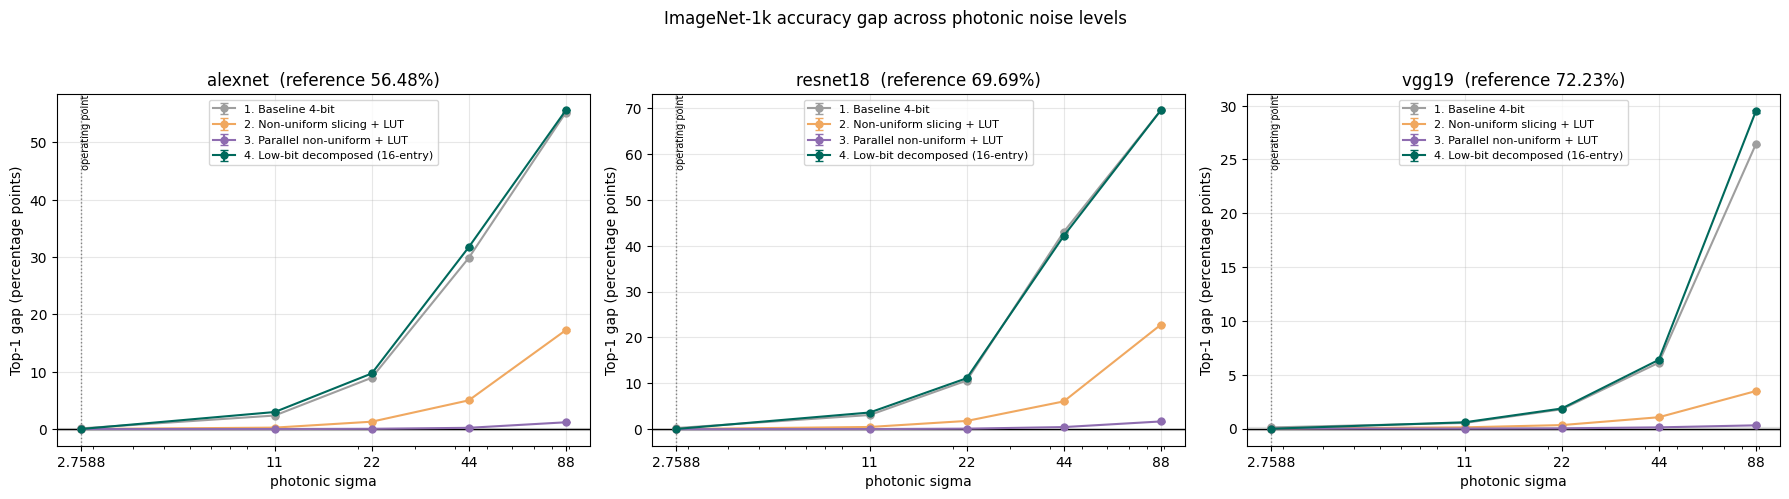

Shaded band is the +/-0.112p practical resolution floor for 50,000 images.


In [11]:
import matplotlib.pyplot as plt
COL = {"base": "#9e9e9e", "nonuni": "#f0a860", "parallel": "#8e6cb0", "lowbit": "#00695c"}
prec = PRECISIONS[0]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4.8), squeeze=False)
for ax, m in zip(axes[0], MODELS):
    ref = RESULTS[(m, "clean", "-", "-", "0")]
    for s_ in SCHEMES:
        g = [ref - stat(m, s_, prec, sg)[0] for sg in SIGMA_SWEEP]
        e = [stat(m, s_, prec, sg)[1] for sg in SIGMA_SWEEP]
        ax.errorbar(SIGMA_SWEEP, g, yerr=e, fmt="o-", ms=5, capsize=3,
                    color=COL[s_], label=SCHEME_LABEL[s_])
    ax.axhline(0, color="black", lw=1)
    ax.axhspan(-RESOLUTION_FLOOR, RESOLUTION_FLOOR, color="black", alpha=0.08)
    ax.axvline(2.7588, color="grey", ls=":", lw=1)
    ax.text(2.7588, ax.get_ylim()[1], " operating point", fontsize=7, va="top", rotation=90)
    ax.set_xscale("log"); ax.set_xticks(SIGMA_SWEEP)
    ax.set_xticklabels([f"{s:g}" for s in SIGMA_SWEEP])
    ax.set_xlabel("photonic sigma"); ax.set_ylabel("Top-1 gap (percentage points)")
    ax.set_title(f"{m}  (reference {ref:.2f}%)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("ImageNet-1k accuracy gap across photonic noise levels", y=1.03)
plt.tight_layout(); plt.show()
print(f"Shaded band is the +/-{RESOLUTION_FLOOR:.3f}p practical resolution floor for "
      f"{EVAL_IMAGES:,} images.")


In [12]:
prec = PRECISIONS[0]
print("=" * 92)
print("INTERPRETATION NOTES")
print("=" * 92)
print()
print("1. PRACTICAL RESOLUTION BAND. At the characterised operating point, differences inside")
print("   the shaded band should not be treated as resolved by this evaluation alone.")
print()
print("2. STRESS SWEEP. Higher sigma values are synthetic stress-test points used to expose")
print("   separation between the numerical correction behaviours.")
print()
print("3. CORNER CORRECTION. The parallel scheme represents the same ideal-table numerical")
print("   MSB-corner correction as the direct 4-bit corner LUT, while using a different")
print("   implementation cost.")
print()
print("4. LOW-BIT CORRECTION. Its component-level advantage at the operating point does not")
print("   translate into the same network-level tolerance as exact MSB-corner correction.")
print()
print("5. BITLUME CONTEXT. BITLUME reports ImageNet training results, whereas this notebook")
print("   applies the characterised error model during inference to pretrained networks.")
print("=" * 92)


INTERPRETATION NOTES

1. PRACTICAL RESOLUTION BAND. At the characterised operating point, differences inside
   the shaded band should not be treated as resolved by this evaluation alone.

2. STRESS SWEEP. Higher sigma values are synthetic stress-test points used to expose
   separation between the numerical correction behaviours.

3. CORNER CORRECTION. The parallel scheme represents the same ideal-table numerical
   MSB-corner correction as the direct 4-bit corner LUT, while using a different
   implementation cost.

4. LOW-BIT CORRECTION. Its component-level advantage at the operating point does not
   translate into the same network-level tolerance as exact MSB-corner correction.

5. BITLUME CONTEXT. BITLUME reports ImageNet training results, whereas this notebook
   applies the characterised error model during inference to pretrained networks.
